# __Übung 1__ Einführung

__Imports__

In [1]:
import pandas as pd

#### __Aufgabe 1__ Pandas (10)

##### Teil 1: Pandas

* Lesen Sie die beiden Dateien bahnstrecken.txt und auslastung.txt in Python ein.


In [5]:
auslastung = pd.read_csv("auslastung.txt", sep="\s+")
bahnstrecken = pd.read_csv("bahnstrecken.txt", sep="\s+")

* Berechnen Sie die Streckenlänge und speichern Sie diese in der Tabelle `bahnstrecken` in einer neuen Spalte ab.

In [23]:
bahnstrecken["Länge"] =(bahnstrecken["Start"] - bahnstrecken["Stop"]).abs()
bahnstrecken

,Strecke,Start,Stop,Länge
0,StreckeA,0,34,34
1,StreckeB,35,56,21
2,StreckeC,57,83,26
3,StreckeD,84,107,23
4,StreckeE,108,130,22
5,StreckeF,131,162,31
6,StreckeG,163,189,26
7,StreckeH,190,204,14


##### Teil 2 Median berechnen 
* Berechnen Sie jeweils für die Ferien und die Werktage den Median der Auslastung je Strecke. (Tipp: `df.median(axis=1)`)
* Beide Mediane sollen Teil der Tabelle `auslastung` werden.

In [11]:
auslastung["Median Ferien"] = auslastung[["Ferien1", "Ferien2"]].median(axis=1)
auslastung["Median Werktage"] = auslastung[["Werktag1", "Werktag2"]].median(axis=1)
auslastung


,Strecke,Ferien1,Ferien2,Werktag1,Werktag2,Median Ferien,Median Werktage
0,StreckeA,11,45,60,74,28.0,67.0
1,StreckeB,40,44,54,88,42.0,71.0
2,StreckeC,96,77,28,38,86.5,33.0
3,StreckeE,63,59,64,58,61.0,61.0
4,StreckeF,75,66,36,19,70.5,27.5
5,StreckeG,84,94,48,43,89.0,45.5


##### Teil 3 DataFrames 

* Verbinden Sie die beiden Tabellen, so dass in der Tabelle `bahnstrecken` beide Medianspalten der Tabelle `auslastung` aufgeführt werden, dabei sollen nur die Strecken enthalten sein, die in beiden Tabellen vorkommen.

In [24]:
bahnstrecken = pd.merge(bahnstrecken, auslastung[["Strecke", "Median Ferien", "Median Werktage"]],
                        on='Strecke', how='inner')
bahnstrecken

,Strecke,Start,Stop,Länge,Median Ferien,Median Werktage
0,StreckeA,0,34,34,28.0,67.0
1,StreckeB,35,56,21,42.0,71.0
2,StreckeC,57,83,26,86.5,33.0
3,StreckeE,108,130,22,61.0,61.0
4,StreckeF,131,162,31,70.5,27.5
5,StreckeG,163,189,26,89.0,45.5


* Berechnen Sie für jede Strecke die Änderung der Auslastung wie folgt: $ log2(\frac{Ferien\_Median}{Werktag\_Median})$. Ergänzen Sie die entsprechende Spalte `Aenderung` in Ihrem neuen Dataframe. Erklären Sie, wann der Wert positiv ist, wann er negativ ist und wann 0.

In [28]:
import numpy as np
bahnstrecken["Änderung"] = np.log2(bahnstrecken["Median Ferien"] / bahnstrecken["Median Werktage"])
bahnstrecken

,Strecke,Start,Stop,Länge,Median Ferien,Median Werktage,Änderung
0,StreckeA,0,34,34,28.0,67.0,-1.258734
1,StreckeB,35,56,21,42.0,71.0,-0.757430
2,StreckeC,57,83,26,86.5,33.0,1.390234
3,StreckeE,108,130,22,61.0,61.0,0.000000
4,StreckeF,131,162,31,70.5,27.5,1.358192
5,StreckeG,163,189,26,89.0,45.5,0.967939


In [ ]:
- Mathematische Definition 
log2 > 1 = Positiv
log2 = 1 => 0
log2 zwischen 0 und 1 => negativ

-Schlussfolgerung da wir das verhältniss von Ferien_Median und Werktag_Median im Log2 betrachten.

In [ ]:
ist die Auslastung im Mittel an Werktagen größer als an Ferientagen ist der Wert positiv.
ist die Auslastung im mittel gleich ist der Wert 0.
ist die Auslastung im Mittel in den Ferientagen größer als an den Werktagen ist der Wert negativ.

SyntaxError: invalid syntax (3181160762.py, line 1)

* Ergänzen Sie eine neue Spalte `behave`, die ein o enthält, wenn die Änderung der Auslastung positiv ist, ein u wenn sie negativ ist, und n sonst.

In [34]:
for x in bahnstrecken.index:
    if bahnstrecken.loc[x, "Änderung"] > 0:
        bahnstrecken.loc[x, "behave"] = "o"
    if bahnstrecken.loc[x, "Änderung"] == 0:
        bahnstrecken.loc[x, "behave"] = "n"
    if bahnstrecken.loc[x, "Änderung"] < 0:
        bahnstrecken.loc[x, "behave"] = "u"
bahnstrecken
    

,Strecke,Start,Stop,Länge,Median Ferien,Median Werktage,Änderung,behave
0,StreckeA,0,34,34,28.0,67.0,-1.258734,u
1,StreckeB,35,56,21,42.0,71.0,-0.757430,u
2,StreckeC,57,83,26,86.5,33.0,1.390234,o
3,StreckeE,108,130,22,61.0,61.0,0.000000,n
4,StreckeF,131,162,31,70.5,27.5,1.358192,o
5,StreckeG,163,189,26,89.0,45.5,0.967939,o


* Stellen Sie die Verteilung von Ferien\_Median und Werktag\_Median als Boxplot gegenüber.

<Axes: >

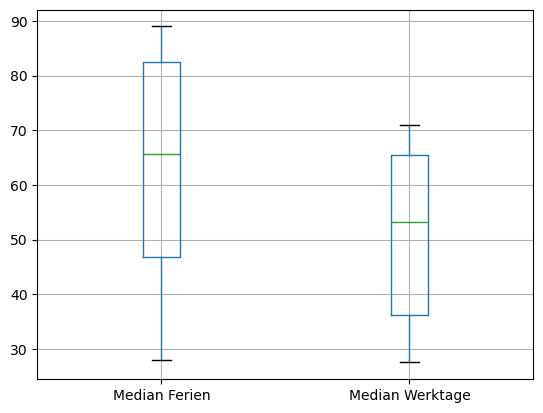

In [36]:
bahnstrecken[["Median Ferien","Median Werktage"]].boxplot()

#### __Aufgabe 2__   Explorative Datenanalyse (10)

Sie haben den Datensatz der US-Steuern aus den Jahren 1974 und 1978. In Zeitungen werden Daten gerne so dargestellt, wie man sie gerade braucht - Steuern sind gesunken bzw. Steuern sind gestiegen. 
Erstellen Sie geeignete Abbildungen, die die jeweilige Intention am besten an die Leser:innen bringt - gerne auch mit eigenen Schlagzeilen je Abbildung. (Sie können dafür auch weitere Berechnungen durchführen).

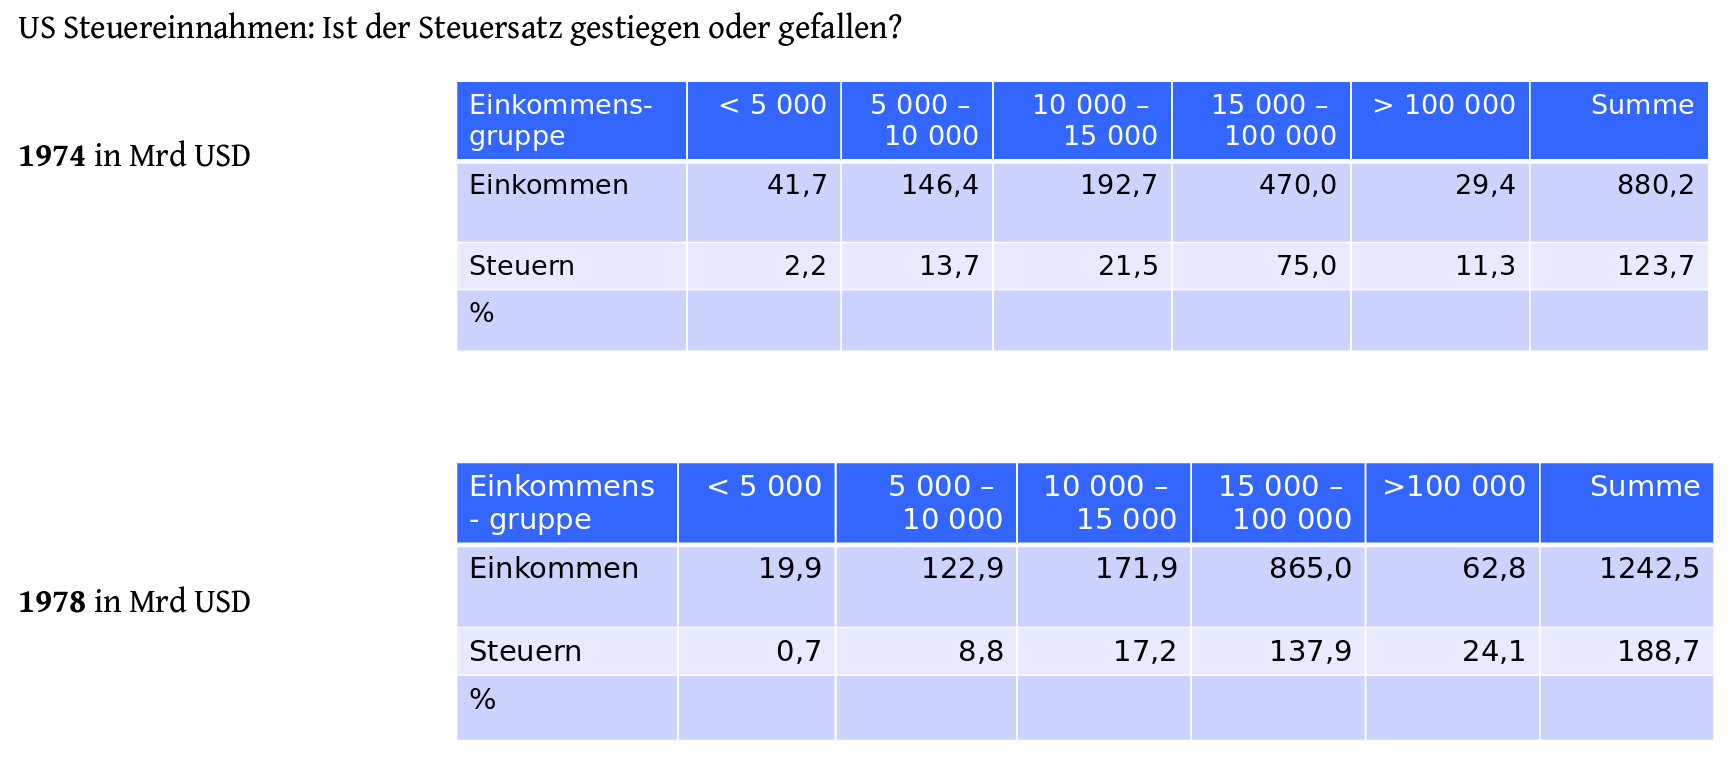



In [55]:
einkommensgruppe = [1, 2, 3, 4, 5, 6]
einkommen74 = [41.7, 146.4, 192.7, 470.0, 29.4, 880.2]
steuern74 = [2.2, 13.7, 21.5, 75, 11.3, 123.7]
steuern78 = [0.7, 8.8, 17.2, 137.9, 24.1, 188.7]
einkommen78 = [19.9, 122.9, 171.9, 865.0, 62.8, 1242.5]

In [63]:
numpy_array74 = np.array([einkommen74, steuern74])
numpy_array78 = np.array([einkommen78, steuern78])
columns = ["< 5000", "5000 - 10000", "10000 - 15000", "15000 - 100000", "> 100000", "Summe"]
raws = ["Einkommen", "Steuern"]

In [64]:
df_74 = pd.DataFrame(numpy_array74, raws, columns)
df_74


,< 5000,5000 - 10000,10000 - 15000,15000 - 100000,> 100000,Summe
Einkommen,41.7,146.4,192.7,470.0,29.4,880.2
Steuern,2.2,13.7,21.5,75.0,11.3,123.7


In [78]:
df_78 = pd.DataFrame(numpy_array78, raws, columns)
df_78

,< 5000,5000 - 10000,10000 - 15000,15000 - 100000,> 100000,Summe
Einkommen,19.9,122.9,171.9,865.0,62.8,1242.5
Steuern,0.7,8.8,17.2,137.9,24.1,188.7


In [81]:
df_78 = df_78.transpose()
df_78

,Einkommen,Steuern
< 5000,19.9,0.7
5000 - 10000,122.9,8.8
10000 - 15000,171.9,17.2
15000 - 100000,865.0,137.9
> 100000,62.8,24.1
Summe,1242.5,188.7


In [82]:
df_74 = df_74.transpose()
df_74

,Einkommen,Steuern
< 5000,41.7,2.2
5000 - 10000,146.4,13.7
10000 - 15000,192.7,21.5
15000 - 100000,470.0,75.0
> 100000,29.4,11.3
Summe,880.2,123.7


In [83]:
df_78["%"] = df_78["Steuern"] / df_78["Einkommen"] * 100
df_78

,Einkommen,Steuern,%
< 5000,19.9,0.7,3.517588
5000 - 10000,122.9,8.8,7.160293
10000 - 15000,171.9,17.2,10.005817
15000 - 100000,865.0,137.9,15.942197
> 100000,62.8,24.1,38.375796
Summe,1242.5,188.7,15.187123


In [84]:
df_74["%"] = df_74["Steuern"] / df_74["Einkommen"] * 100
df_74

,Einkommen,Steuern,%
< 5000,41.7,2.2,5.275779
5000 - 10000,146.4,13.7,9.357923
10000 - 15000,192.7,21.5,11.157239
15000 - 100000,470.0,75.0,15.957447
> 100000,29.4,11.3,38.435374
Summe,880.2,123.7,14.053624


In [103]:
df_vergleich= pd.DataFrame()
df_vergleich["1974"] = df_74["%"]
df_vergleich["1978"] = df_78["%"]
df_vergleich

,1974,1978
< 5000,5.275779,3.517588
5000 - 10000,9.357923,7.160293
10000 - 15000,11.157239,10.005817
15000 - 100000,15.957447,15.942197
> 100000,38.435374,38.375796
Summe,14.053624,15.187123


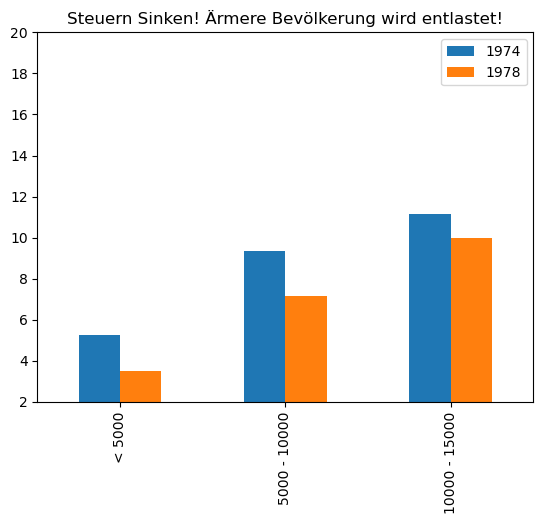

In [115]:
import matplotlib.pyplot as plt
plot = df_vergleich[["1974", "1978"]].iloc[:-3].plot(title="Steuern Sinken! Ärmere Bevölkerung wird entlastet!", kind="bar")
plot.set_ylim(2, 20)
plt.show()

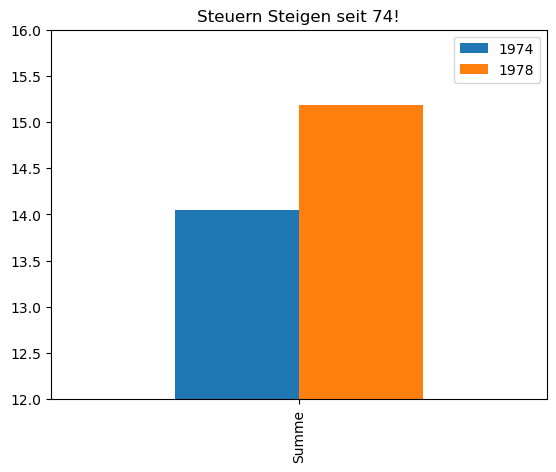

In [112]:
import matplotlib.pyplot as plt
plot = df_vergleich[["1974", "1978"]].iloc[-1:].plot(title="Steuern Steigen seit 74!", kind="bar")
plot.set_ylim(12, 16)
plt.show()